In [283]:
using Plots,JLD2,LinearAlgebra

In [284]:
Nx=24
Ny=24
tper=-0.37

tpa=2.0
tNNN=-0.08

α=-1.5
temp=0.09
β=0.15
K=1.0;
KNNN=0.0;
gshear=0.1
trytime_record=1

filling=1.25
#trytime=1

1.25

In [285]:
st=load("test.jld2")
   

Dict{String, Any} with 14 entries:
  "Eelec"          => -2.3988
  "grad"           => [0.000200125, -0.000244051, 0.000175586, -0.000237712, 0.…
  "spectrum"       => [-4.74228, -4.74223, -4.71716, -4.71716, -4.71711, -4.717…
  "max_record"     => 0.127764
  "average_record" => 0.0870135
  "record_cal"     => Vector{Any}[[-2.36982, -2.37144, -2.36326, -2.36119, -2.3…
  "orbital_id"     => [1 25 … 529 553; 2 26 … 530 554; … ; 23 47 … 551 575; 24 …
  "phonon_id"      => [1 25 … 529 553; 2 26 … 530 554; … ; 23 47 … 551 575; 24 …
  "phonon_coor"    => [-0.0871875, 0.037586, 0.027207, -0.0862126, 0.0836791, -…
  "FL"             => 1.51223
  "ave_npa"        => 720.0
  "E_total"        => -2.38153
  "Egap"           => 0.232239
  "free_energy"    => -2.38184

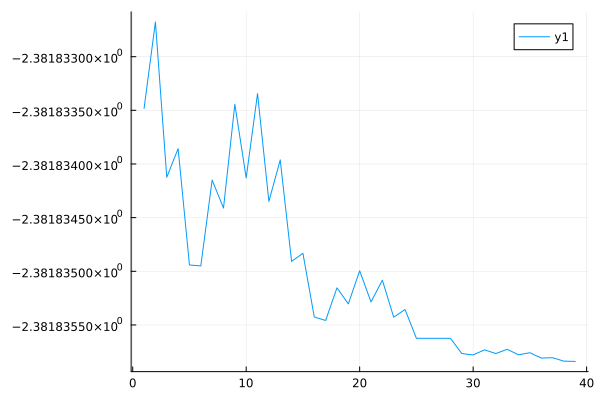

In [286]:
plot(st["record_cal"][1][100:end])

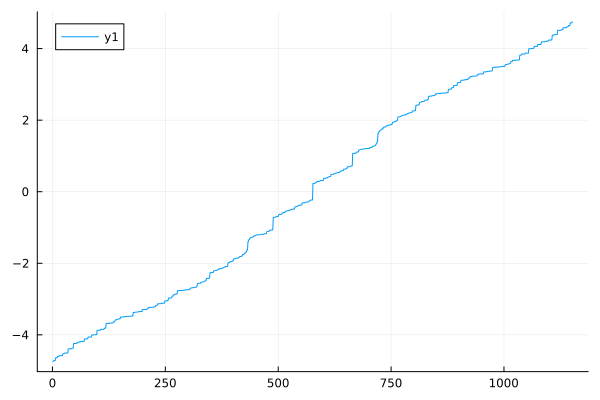

In [287]:
plot(sort(st["spectrum"]))

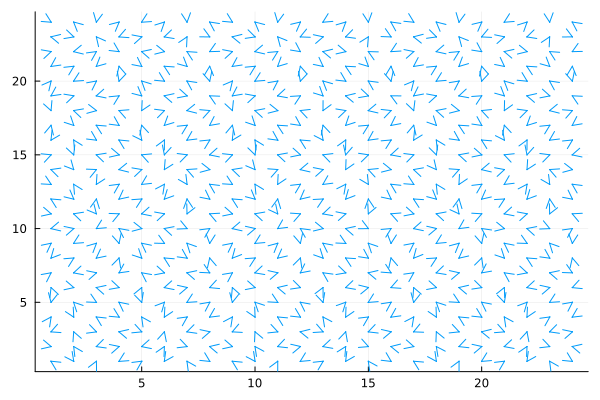

In [288]:
phonon_coor=st["phonon_coor"]
phonon_id=st["phonon_id"]
atom_x=zeros(Float64,Nx,Ny)
atom_y=zeros(Float64,Nx,Ny)
dis_x=zeros(Float64,Nx,Ny)
dis_y=zeros(Float64,Nx,Ny)

for ja in 1:Nx, jb in 1:Ny
    atom_x[ja,jb]=ja
    atom_y[ja,jb]=jb
    dis_x[ja,jb]=phonon_coor[phonon_id[ja,jb,1]]+ja
    dis_y[ja,jb]=phonon_coor[phonon_id[ja,jb,2]]+jb
    
end

dis_x=dis_x .- atom_x
dis_y=dis_y .- atom_y
p1=quiver(vec(atom_x),vec(atom_y),quiver=(0.1*vec(dis_x),0.1*vec(dis_y)))




In [289]:
#savefig(p1,"quiverplot.png")

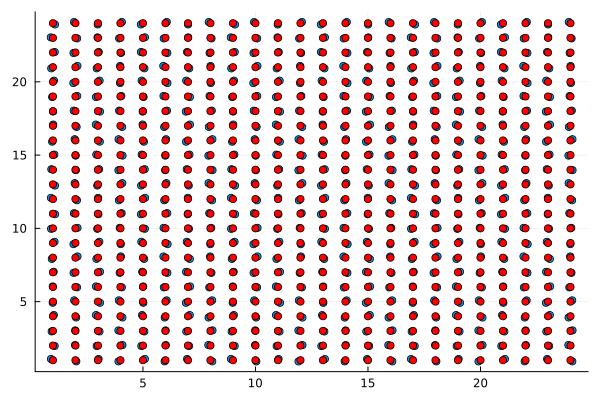

In [290]:
phonon_coor=st["phonon_coor"]
phonon_id=st["phonon_id"]
atom_x=zeros(Float64,Nx,Ny)
atom_y=zeros(Float64,Nx,Ny)
dis_x=zeros(Float64,Nx,Ny)
dis_y=zeros(Float64,Nx,Ny)

for ja in 1:Nx, jb in 1:Ny
    atom_x[ja,jb]=ja
    atom_y[ja,jb]=jb
    dis_x[ja,jb]=phonon_coor[phonon_id[ja,jb,1]]+ja
    dis_y[ja,jb]=phonon_coor[phonon_id[ja,jb,2]]+jb
    
end


p2=scatter(vec(dis_x),vec(dis_y))
scatter!(vec(atom_x),vec(atom_y),color=:red,legend=:false)

In [291]:
#savefig(p2,"atomplot.png")

In [292]:
sort(vec(dis_y)-vec(atom_y))

576-element Vector{Float64}:
 -0.08838339055997224
 -0.08837105480185414
 -0.08807051705460012
 -0.08797260477892088
 -0.0878782399913387
 -0.08779430990391113
 -0.08765152569931356
 -0.08752828154101344
 -0.08752516207385597
 -0.08743114910200234
  ⋮
  0.08625562758985339
  0.08635797613494445
  0.08653039063838008
  0.086552128035291
  0.08657575617303337
  0.08660629145933996
  0.08681897753329881
  0.08690046880987445
  0.08705204797923827

In [293]:
sort(vec(sqrt.(dis_x.^2+dis_y.^2)))

576-element Vector{Float64}:
  1.4184771557002969
  2.235933942044782
  2.245794541462303
  2.843459219144245
  3.110511358823268
  3.216083327306259
  3.5418671271217836
  3.63024446380575
  4.020610947176785
  4.2150739393965635
  ⋮
 31.765238906102546
 31.824171309942297
 31.950090983659514
 32.509869201322275
 32.56080859930568
 32.65752339846195
 33.18516038203063
 33.250826190906224
 33.94658638665916

In [294]:
sum(vec(sqrt.(dis_x.^2+dis_y.^2)))/(Nx*Ny)

19.01286522605226

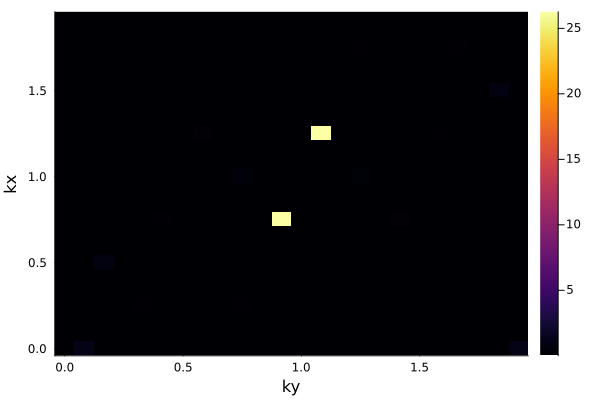

In [295]:
kx_space=2π*collect(0:1:Nx-1)/Nx
ky_space=2π*collect(0:1:Ny-1)/Ny
Fourier_mode_x=zeros(ComplexF64,length(kx_space),length(ky_space))
for ja in eachindex(kx_space), jb in eachindex(ky_space)
    kx=kx_space[ja]
    ky=ky_space[jb]
    for jc in 1:Nx, jd in 1:Ny, xp in -0:0, yp in -0:0
    Fourier_mode_x[ja,jb]+=phonon_coor[phonon_id[jc,jd,1]]*exp(-im*(kx*(jc+xp*Nx)+ky*(jd+yp*Ny)))
    end

end

heatmap(ky_space/pi,kx_space/pi,abs.(Fourier_mode_x),xlabel="ky",ylabel="kx")

In [296]:
sort(vec(abs.(Fourier_mode_x)))

576-element Vector{Float64}:
  7.91033905045424e-16
  1.925240411482556e-15
  2.4005451258785836e-15
  2.7002037929372515e-15
  3.4938423565277577e-15
  3.608342579052703e-15
  5.054627942351247e-15
  5.120206746771444e-15
  5.389343192342563e-15
  5.777875426168849e-15
  ⋮
  0.1774324806696212
  0.3440849655200703
  0.3440849655200764
  0.7200157635268583
  0.7200157635268617
  0.9452235895560565
  0.9452235895560586
 26.2650091360253
 26.265009136025313

In [297]:
findmax(abs.(Fourier_mode_x))

(26.265009136025313, CartesianIndex(10, 12))

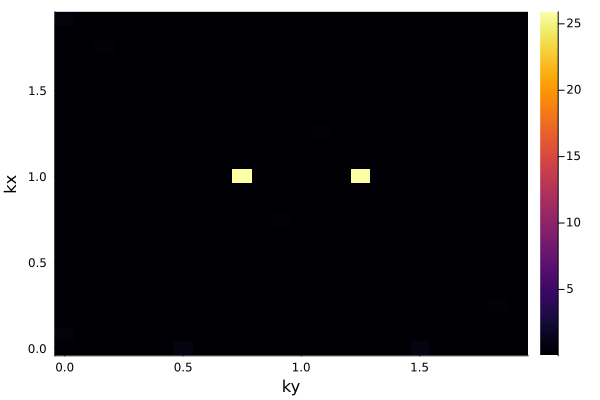

In [298]:
kx_space=2π*collect(0:1:Nx-1)/Nx
ky_space=2π*collect(0:1:Ny-1)/Ny
Fourier_mode_y=zeros(ComplexF64,length(kx_space),length(ky_space))
for ja in eachindex(kx_space), jb in eachindex(ky_space)
    kx=kx_space[ja]
    ky=ky_space[jb]
    for jc in 1:Nx, jd in 1:Ny, xp in -0:0, yp in -0:0
    Fourier_mode_y[ja,jb]+=phonon_coor[phonon_id[jc,jd,2]]*exp(-im*(kx*(jc+xp*Nx)+ky*(jd+yp*Ny)))
    end

end

heatmap(ky_space/pi,kx_space/pi,abs.(Fourier_mode_y),xlabel="ky",ylabel="kx")

In [299]:
findmax(abs.(Fourier_mode_y))

(25.904710993134554, CartesianIndex(13, 10))

In [300]:
Fourier_mode_y[8,14]

-2.7945051737782167e-6 + 2.6333997638582144e-6im

In [301]:
Fourier_mode_x[8,14]

-4.6685393012751986e-5 + 4.261761768786388e-5im

In [302]:
Fourier_mode_y[14,8]

-7.311785965580242e-8 - 1.705699884917837e-8im

In [303]:
Fourier_mode_x[14,8]

1.9106253551504082e-8 - 3.521316231628838e-7im

In [304]:
Fourier_mode_y[8,8]

0.00018102200820713232 + 7.206784665716219e-7im

In [305]:
Fourier_mode_x[8,8]

-0.00023583090815323948 - 9.690651776688068e-7im